# Keep-alive

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install and Imports

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Bidirectional,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import MobileNetV2
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import warnings, pickle
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


# Configuration
Winners from Model_Comparison.ipynb: **BiLSTM** + **MobileNetV2 / Candlestick**

In [ ]:
MODELS_DIR   = '/content/drive/MyDrive/DMIF/models'
LSTM_PATH    = f'{MODELS_DIR}/lstm_bilstm.keras'
CNN_PATH     = f'{MODELS_DIR}/cnn_mobilenet_candlestick.keras'

CSV_PATH     = '/content/drive/MyDrive/DMIF/master_dataset_clean_80.csv'
LOCAL_CSV    = '/content/master_dataset.csv'
INDEX_PATH   = '/content/drive/MyDrive/DMIF/chart_index_final.csv'

ZIP_PATH     = '/content/drive/MyDrive/DMIF/candlestick_images.zip'
LOCAL_ZIP    = '/content/candlestick_images.zip'
LOCAL_CHARTS = '/content/charts_local'

SEQ_LEN      = 30
IMG_SIZE     = 64
BATCH_SIZE   = 32
CHART_TYPE   = 'candlestick'

LSTM_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Log_Volume',
    'Daily_Return', 'Log_Return', 'HL_Range', 'OC_Range',
    'MA_24', 'MA_30', 'MA_500',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Middle', 'BB_Width',
    'Volatility_10', 'SAR', 'SAR_Trend',
    'Fib_0236', 'Fib_0382', 'Fib_05', 'Fib_0618', 'Fib_0786',
    'Volume_MA_10', 'Volume_Ratio'
]

print(f"LSTM path : {LSTM_PATH}")
print(f"CNN  path : {CNN_PATH}")

LSTM path : /content/drive/MyDrive/DMIF/models/lstm_bilstm.keras
CNN  path : /content/drive/MyDrive/DMIF/models/cnn_mobilenet_candlestick.keras


# Load Both Trained Models

In [ ]:
print("Loading BiLSTM...")
lstm_model = load_model(LSTM_PATH)
print("BiLSTM loaded")

print("Loading MobileNetV2 (candlestick)...")
cnn_model = load_model(CNN_PATH)
print("CNN loaded")

Loading BiLSTM...
BiLSTM loaded
Loading MobileNetV2 (candlestick)...
CNN loaded


# Inspect Chart Index Columns
Check the exact column names before joining — do not assume.

In [ ]:
index_df = pd.read_csv(INDEX_PATH)
print("Columns:", list(index_df.columns))
print()
print(index_df.head(3).to_string())
print()
print(f"Total rows: {len(index_df)}")
print(f"chart_type values: {index_df['chart_type'].unique()}")

Columns: ['path', 'label', 'company', 'chart_type', 'filename']

                                                                                 path  label company   chart_type                             filename
0  /content/drive/MyDrive/DMIF/charts_final/AAF.N/AAF.N_candlestick_20120229_DOWN.png      0   AAF.N  candlestick  AAF.N_candlestick_20120229_DOWN.png
1  /content/drive/MyDrive/DMIF/charts_final/AAF.N/AAF.N_candlestick_20120308_DOWN.png      0   AAF.N  candlestick  AAF.N_candlestick_20120308_DOWN.png
2    /content/drive/MyDrive/DMIF/charts_final/AAF.N/AAF.N_candlestick_20120315_UP.png      1   AAF.N  candlestick    AAF.N_candlestick_20120315_UP.png

Total rows: 111104
chart_type values: ['candlestick' 'heatmap']


# Rebuild LSTM Sequences (per company, with dates kept)


In [ ]:
import shutil

print("Copying CSV to local disk...")
shutil.copy(CSV_PATH, LOCAL_CSV)

df = pd.read_csv(LOCAL_CSV, parse_dates=['Date'])
df = df.sort_values(['Company_Code', 'Date']).reset_index(drop=True)

print(f"Loaded: {df.shape[0]} rows, {df['Company_Code'].nunique()} companies")

all_X, all_y, all_company, all_date = [], [], [], []

companies = sorted(df['Company_Code'].unique())

for company in companies:
    company_df = df[df['Company_Code'] == company].copy()
    company_df = company_df.sort_values('Date').reset_index(drop=True)
    company_df = company_df.dropna(subset=LSTM_FEATURES + ['Target'])

    if len(company_df) < SEQ_LEN + 1:
        continue

    train_end = int(len(company_df) * 0.7)
    scaler = MinMaxScaler()
    scaler.fit(company_df[LSTM_FEATURES].iloc[:train_end])

    scaled  = scaler.transform(company_df[LSTM_FEATURES])
    targets = company_df['Target'].values
    dates   = company_df['Date'].values

    for i in range(SEQ_LEN, len(company_df) - 1):
        all_X.append(scaled[i-SEQ_LEN:i])
        all_y.append(targets[i])
        all_company.append(company)
        all_date.append(pd.Timestamp(dates[i]).strftime('%Y-%m-%d'))

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

lstm_meta = pd.DataFrame({
    'company': all_company,
    'date'   : all_date,
    'label'  : all_y
})
lstm_meta['seq_idx'] = np.arange(len(lstm_meta))

print(f"Total LSTM sequences: {len(all_X)}")
print(lstm_meta.head())

Copying CSV to local disk...
Loaded: 323998 rows, 80 companies
Total LSTM sequences: 321518
  company        date  label  seq_idx
0   AAF.N  2012-02-29    0.0        0
1   AAF.N  2012-03-01    0.0        1
2   AAF.N  2012-03-02    0.0        2
3   AAF.N  2012-03-05    0.0        3
4   AAF.N  2012-03-06    1.0        4


# Get LSTM Probabilities for Every Sequence

In [ ]:
print("Running BiLSTM inference on all sequences...")
lstm_probs_all = lstm_model.predict(all_X, verbose=1, batch_size=256).flatten()
lstm_meta['lstm_prob'] = lstm_probs_all
print("Done")
print(lstm_meta.head())

Running BiLSTM inference on all sequences...
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 97s 77ms/step
Done
  company        date  label  seq_idx  lstm_prob
0   AAF.N  2012-02-29    0.0        0   0.417997
1   AAF.N  2012-03-01    0.0        1   0.416765
2   AAF.N  2012-03-02    0.0        2   0.414092
3   AAF.N  2012-03-05    0.0        3   0.409868
4   AAF.N  2012-03-06    1.0        4   0.410507


# Load CNN Chart Index (candlestick only) and Extract Images

In [ ]:
import zipfile

filtered = index_df[index_df['chart_type'] == CHART_TYPE].copy().reset_index(drop=True)
print(f"Candlestick entries in index: {len(filtered)}")

print("Copying zip from Drive...")
shutil.copy2(ZIP_PATH, LOCAL_ZIP)
os.makedirs(LOCAL_CHARTS, exist_ok=True)
with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
    z.extractall(LOCAL_CHARTS)
print("Extracted")

updated_paths = []
for _, row in filtered.iterrows():
    company    = row['company']
    filename   = row['filename']
    local_path = os.path.join(LOCAL_CHARTS, f"{company}_{filename}")
    updated_paths.append(local_path if os.path.exists(local_path) else None)

filtered['local_path'] = updated_paths
before = len(filtered)
filtered = filtered[filtered['local_path'].notna()].reset_index(drop=True)
print(f"Usable images: {len(filtered)}  (missing: {before - len(filtered)})")

Candlestick entries in index: 46766
Copying zip from Drive...
Extracted
Usable images: 46766  (missing: 0)


# Corrupt Image Scan

In [ ]:
from PIL import Image

bad_paths = []
for p in filtered['local_path']:
    try:
        Image.open(p).verify()
    except Exception:
        bad_paths.append(p)

if bad_paths:
    print(f"Found {len(bad_paths)} corrupt file(s) — removing")
    filtered = filtered[~filtered['local_path'].isin(bad_paths)].reset_index(drop=True)
else:
    print("No corrupt images found.")

print(f"Usable images after scan: {len(filtered)}")

No corrupt images found.
Usable images after scan: 46766


# Get CNN Probabilities for Every Chart

In [ ]:
def load_and_predict_batch(paths, model, img_size, batch_size=64):
    probs = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            img = tf.io.read_file(p)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, [img_size, img_size])
            img = tf.cast(img, tf.float32) / 255.0
            imgs.append(img)
        batch = tf.stack(imgs)
        p = model(batch, training=False).numpy().flatten()
        probs.extend(p)
        if i % (batch_size*20) == 0:
            print(f"  {i}/{len(paths)}")
    return np.array(probs)

# Extract date from filename: AAF.N_candlestick_20120229_DOWN.png -> 20120229
filtered['date'] = filtered['filename'].str.split('_').str[2]
filtered['date'] = pd.to_datetime(filtered['date'], format='%Y%m%d').dt.strftime('%Y-%m-%d')

print("Sample extracted dates:")
print(filtered[['filename', 'date']].head())

print("\nRunning MobileNetV2 inference on all candlestick charts...")
cnn_probs_all = load_and_predict_batch(filtered['local_path'].values, cnn_model, IMG_SIZE)
filtered['cnn_prob'] = cnn_probs_all
print("Done")
print(filtered[['company', 'date', 'label', 'cnn_prob']].head())

Sample extracted dates:
                              filename        date
0  AAF.N_candlestick_20120229_DOWN.png  2012-02-29
1  AAF.N_candlestick_20120308_DOWN.png  2012-03-08
2    AAF.N_candlestick_20120315_UP.png  2012-03-15
3  AAF.N_candlestick_20120322_DOWN.png  2012-03-22
4  AAF.N_candlestick_20120329_DOWN.png  2012-03-29

Running MobileNetV2 inference on all candlestick charts...
  0/46766
  1280/46766
  2560/46766
  3840/46766
  5120/46766
  6400/46766
  7680/46766
  8960/46766
  10240/46766
  11520/46766
  12800/46766
  14080/46766
  15360/46766
  16640/46766
  17920/46766
  19200/46766
  20480/46766
  21760/46766
  23040/46766
  24320/46766
  25600/46766
  26880/46766
  28160/46766
  29440/46766
  30720/46766
  32000/46766
  33280/46766
  34560/46766
  35840/46766
  37120/46766
  38400/46766
  39680/46766
  40960/46766
  42240/46766
  43520/46766
  44800/46766
  46080/46766
Done
  company        date  label  cnn_prob
0   AAF.N  2012-02-29      0  0.499454
1   AAF.N  2012-03-0

# Join LSTM and CNN Predictions on (company, date)


In [ ]:
# Normalize date format on the CNN side to match LSTM (YYYY-MM-DD strings)
cnn_meta = filtered[['company', 'date', 'label', 'cnn_prob']].copy()
cnn_meta['date'] = pd.to_datetime(cnn_meta['date']).dt.strftime('%Y-%m-%d')

merged = pd.merge(
    lstm_meta[['company', 'date', 'label', 'lstm_prob']],
    cnn_meta[['company', 'date', 'cnn_prob']],
    on=['company', 'date'],
    how='inner'
)

print(f"LSTM sequences : {len(lstm_meta)}")
print(f"CNN charts     : {len(cnn_meta)}")
print(f"Matched pairs  : {len(merged)}")

if len(merged) == 0:
    print("\nWARNING: No matches found — check the date format / column name from the")
    print("chart index inspection cell above and adjust the join accordingly.")
else:
    print(merged.head())

LSTM sequences : 321518
CNN charts     : 46766
Matched pairs  : 46805
  company        date  label  lstm_prob  cnn_prob
0   AAF.N  2012-02-29    0.0   0.417997  0.499454
1   AAF.N  2012-03-08    0.0   0.410228  0.510751
2   AAF.N  2012-03-15    1.0   0.424210  0.502495
3   AAF.N  2012-03-22    0.0   0.426672  0.504681
4   AAF.N  2012-03-29    0.0   0.427937  0.489494


# Chronological Split of Matched Pairs


In [ ]:
merged = merged.sort_values('date').reset_index(drop=True)

n         = len(merged)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

fusion_train = merged.iloc[:train_end].reset_index(drop=True)
fusion_val   = merged.iloc[train_end:val_end].reset_index(drop=True)
fusion_test  = merged.iloc[val_end:].reset_index(drop=True)

print(f"Fusion Train : {len(fusion_train)} | UP: {fusion_train['label'].mean()*100:.1f}%")
print(f"Fusion Val   : {len(fusion_val)}   | UP: {fusion_val['label'].mean()*100:.1f}%")
print(f"Fusion Test  : {len(fusion_test)}  | UP: {fusion_test['label'].mean()*100:.1f}%")

Fusion Train : 32763 | UP: 33.5%
Fusion Val   : 4681   | UP: 35.5%
Fusion Test  : 9361  | UP: 35.3%


# Train the Fusion Meta-Learner (Logistic Regression)

In [ ]:
X_fusion_train = fusion_train[['lstm_prob', 'cnn_prob']].values
y_fusion_train = fusion_train['label'].values

X_fusion_val = fusion_val[['lstm_prob', 'cnn_prob']].values
y_fusion_val = fusion_val['label'].values

X_fusion_test = fusion_test[['lstm_prob', 'cnn_prob']].values
y_fusion_test = fusion_test['label'].values

fusion_clf = LogisticRegression(C=1.0, max_iter=1000)
fusion_clf.fit(X_fusion_train, y_fusion_train)

weights = fusion_clf.coef_[0]
weights_norm = weights / weights.sum()

print(f"Raw coefficients   : LSTM={weights[0]:.4f}  CNN={weights[1]:.4f}")
print(f"Normalized weights : LSTM={weights_norm[0]:.4f}  CNN={weights_norm[1]:.4f}")
print(f"Intercept          : {fusion_clf.intercept_[0]:.4f}")

Raw coefficients   : LSTM=4.5841  CNN=3.1714
Normalized weights : LSTM=0.5911  CNN=0.4089
Intercept          : -4.4958


# Threshold Tuning (macro F1 on fusion validation set)

In [ ]:
fusion_va_probs = fusion_clf.predict_proba(X_fusion_val)[:, 1]

best_thresh, best_macro_f1 = 0.5, 0
for thresh in np.arange(0.30, 0.71, 0.01):
    preds = (fusion_va_probs >= thresh).astype(int)
    macro_f1 = f1_score(y_fusion_val, preds, average='macro')
    if macro_f1 > best_macro_f1:
        best_macro_f1, best_thresh = macro_f1, thresh

default_macro_f1 = f1_score(y_fusion_val, (fusion_va_probs >= 0.5).astype(int), average='macro')

print(f"Best threshold (macro F1) : {best_thresh:.2f}")
print(f"Macro F1 at best threshold: {best_macro_f1:.4f}")
print(f"Macro F1 at default 0.5   : {default_macro_f1:.4f}")

Best threshold (macro F1) : 0.35
Macro F1 at best threshold: 0.5445
Macro F1 at default 0.5   : 0.3920


# Evaluate Fusion — Full Metrics

In [ ]:
fusion_te_probs = fusion_clf.predict_proba(X_fusion_test)[:, 1]
fusion_te_preds = (fusion_te_probs >= best_thresh).astype(int)

fusion_acc       = accuracy_score(y_fusion_test, fusion_te_preds)
fusion_precision = precision_score(y_fusion_test, fusion_te_preds)
fusion_recall    = recall_score(y_fusion_test, fusion_te_preds)
fusion_f1        = f1_score(y_fusion_test, fusion_te_preds)
fusion_roc_auc   = roc_auc_score(y_fusion_test, fusion_te_probs)
fusion_cm        = confusion_matrix(y_fusion_test, fusion_te_preds)

print(f"{'='*55}")
print(f"FUSION LAYER — Test Set Results")
print(f"{'='*55}")
print(f"Test Accuracy  : {fusion_acc:.4f}")
print(f"Precision (UP) : {fusion_precision:.4f}")
print(f"Recall    (UP) : {fusion_recall:.4f}")
print(f"F1-Score  (UP) : {fusion_f1:.4f}")
print(f"ROC-AUC        : {fusion_roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_fusion_test, fusion_te_preds, target_names=['DOWN', 'UP']))
print(f"Confusion Matrix:")
print(fusion_cm)
print(f"{'='*55}")

FUSION LAYER — Test Set Results
Test Accuracy  : 0.5830
Precision (UP) : 0.4199
Recall    (UP) : 0.4797
F1-Score  (UP) : 0.4478
ROC-AUC        : 0.5857

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.69      0.64      0.66      6061
          UP       0.42      0.48      0.45      3300

    accuracy                           0.58      9361
   macro avg       0.56      0.56      0.56      9361
weighted avg       0.60      0.58      0.59      9361

Confusion Matrix:
[[3874 2187]
 [1717 1583]]


# Compare — LSTM alone vs CNN alone vs Fusion


            Model  Accuracy  F1 (UP)  ROC-AUC
     BiLSTM alone    0.5678   0.4450   0.5744
MobileNetV2 alone    0.5696   0.4012   0.5582
      Fusion (LR)    0.5830   0.4478   0.5857


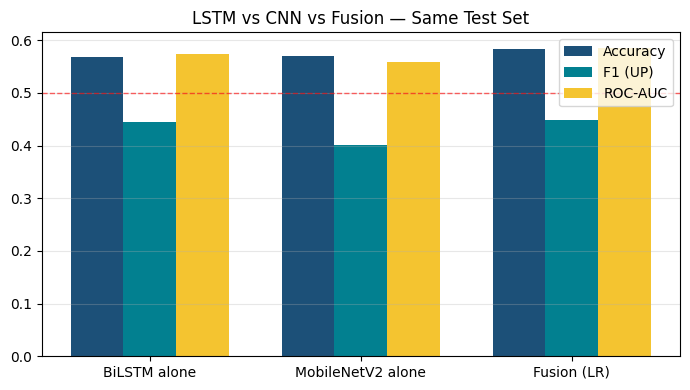

Saved: /content/drive/MyDrive/DMIF/models/fusion_vs_individual_comparison.png


In [ ]:
lstm_solo_preds = (fusion_test['lstm_prob'].values >= 0.5).astype(int)
cnn_solo_preds  = (fusion_test['cnn_prob'].values  >= 0.5).astype(int)

comparison = pd.DataFrame({
    'Model'   : ['BiLSTM alone', 'MobileNetV2 alone', 'Fusion (LR)'],
    'Accuracy': [
        accuracy_score(y_fusion_test, lstm_solo_preds),
        accuracy_score(y_fusion_test, cnn_solo_preds),
        fusion_acc
    ],
    'F1 (UP)' : [
        f1_score(y_fusion_test, lstm_solo_preds),
        f1_score(y_fusion_test, cnn_solo_preds),
        fusion_f1
    ],
    'ROC-AUC' : [
        roc_auc_score(y_fusion_test, fusion_test['lstm_prob'].values),
        roc_auc_score(y_fusion_test, fusion_test['cnn_prob'].values),
        fusion_roc_auc
    ]
})

print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(comparison))
width = 0.25
ax.bar(x - width, comparison['Accuracy'], width, label='Accuracy', color='#1C5078')
ax.bar(x,          comparison['F1 (UP)'],  width, label='F1 (UP)',  color='#028090')
ax.bar(x + width,  comparison['ROC-AUC'],  width, label='ROC-AUC',  color='#F4C430')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.legend()
ax.set_title('LSTM vs CNN vs Fusion — Same Test Set')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

compare_path = f'{MODELS_DIR}/fusion_vs_individual_comparison.png'
plt.savefig(compare_path, dpi=120)
plt.show()
print(f"Saved: {compare_path}")

# Confusion Matrix Plot — Fusion

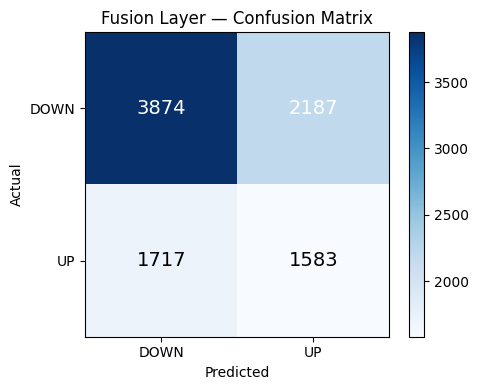

Saved: /content/drive/MyDrive/DMIF/models/fusion_confusion_matrix.png


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(fusion_cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(fusion_cm[i, j]), ha='center', va='center',
                color='white' if fusion_cm[i, j] > fusion_cm.max()/2 else 'black', fontsize=14)

ax.set_xticks([0, 1]); ax.set_xticklabels(['DOWN', 'UP'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['DOWN', 'UP'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Fusion Layer — Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()

cm_path = f'{MODELS_DIR}/fusion_confusion_matrix.png'
plt.savefig(cm_path)
plt.show()
print(f"Saved: {cm_path}")

# Save Fusion Bundle


In [ ]:
bundle = {
    'fusion_clf'      : fusion_clf,
    'weights_raw'     : weights.tolist(),
    'weights_norm'    : weights_norm.tolist(),
    'best_threshold'  : float(best_thresh),
    'lstm_model_path' : LSTM_PATH,
    'cnn_model_path'  : CNN_PATH,
    'seq_len'         : SEQ_LEN,
    'img_size'        : IMG_SIZE,
    'lstm_features'   : LSTM_FEATURES,
}

bundle_path = f'{MODELS_DIR}/fusion_bundle.pkl'
with open(bundle_path, 'wb') as f:
    pickle.dump(bundle, f)

print(f"Fusion bundle saved: {bundle_path}")

results = {
    'best_lstm'        : 'bilstm',
    'best_cnn'         : 'mobilenet_candlestick',
    'test_accuracy'    : float(fusion_acc),
    'precision_up'     : float(fusion_precision),
    'recall_up'        : float(fusion_recall),
    'f1_score_up'      : float(fusion_f1),
    'roc_auc'          : float(fusion_roc_auc),
    'confusion_matrix' : fusion_cm.tolist(),
    'best_threshold'   : float(best_thresh),
    'weights_norm'     : weights_norm.tolist(),
    'train_samples'    : len(fusion_train),
    'val_samples'      : len(fusion_val),
    'test_samples'     : len(fusion_test),
    'comparison_vs_individual': comparison.to_dict(orient='records')
}

results_path = f'{MODELS_DIR}/fusion_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Fusion results saved: {results_path}")
print()
print(json.dumps(results, indent=2))

Fusion bundle saved: /content/drive/MyDrive/DMIF/models/fusion_bundle.pkl
Fusion results saved: /content/drive/MyDrive/DMIF/models/fusion_results.json

{
  "best_lstm": "bilstm",
  "best_cnn": "mobilenet_candlestick",
  "test_accuracy": 0.5829505394722786,
  "precision_up": 0.419893899204244,
  "recall_up": 0.4796969696969697,
  "f1_score_up": 0.4478076379066478,
  "roc_auc": 0.5856696314739541,
  "confusion_matrix": [
    [
      3874,
      2187
    ],
    [
      1717,
      1583
    ]
  ],
  "best_threshold": 0.35000000000000003,
  "weights_norm": [
    0.5910796920055955,
    0.4089203079944045
  ],
  "train_samples": 32763,
  "val_samples": 4681,
  "test_samples": 9361,
  "comparison_vs_individual": [
    {
      "Model": "BiLSTM alone",
      "Accuracy": 0.567781219955133,
      "F1 (UP)": 0.44499314128943757,
      "ROC-AUC": 0.5744043887147335
    },
    {
      "Model": "MobileNetV2 alone",
      "Accuracy": 0.5695972652494392,
      "F1 (UP)": 0.4012483281319661,
      "ROC-